# Parquet 파일 구성 확인

SO100 VR 텔레옵 데이터셋의 parquet 파일 구조와 내용을 분석합니다.


In [57]:
# 라이브러리 로드
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
import yaml
import json
from typing import Dict, List
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("✅ 필수 라이브러리 로드 완료")

✅ 필수 라이브러리 로드 완료


In [58]:
# Config 로드 및 데이터셋 경로 설정
config_path = Path("/home/choyunsang/lerobot/config.yaml")
chunk_num = 000
file_num = 000

try:
    with open(config_path) as f:
        config = yaml.safe_load(f)
    dataset_root = Path(config["dataset"]["root"])
    repo_id = config["dataset"]["repo_id"]
    task_name = config["dataset"]["task_name"]
    print(f"✅ Config 로드 완료")
    print(f"   - Dataset root: {dataset_root}")
    print(f"   - Repo ID: {repo_id}")
    print(f"   - Task Name: {task_name}")
except Exception as e:
    # Fallback 기본값
    dataset_root = Path.home() / "Dataset"
    repo_id = "so100_vr_record"
    print(f"⚠️  Config 로드 실패, 기본값 사용: {e}")
    print(f"   - Dataset root: {dataset_root}")
    print(f"   - Repo ID: {repo_id}")
    print(f"   - Task Name: {task_name}")

# 데이터셋 경로
dataset_path = dataset_root.joinpath(task_name)
chunk_path = dataset_path.joinpath("data", f"chunk-{chunk_num:03d}")

print(f"\n📁 데이터셋 경로: {dataset_path}")
print(f"📁 Chunk 경로: {chunk_path}")
print(f"   - 존재 여부: {chunk_path.exists()}")

✅ Config 로드 완료
   - Dataset root: /home/choyunsang/Dataset
   - Repo ID: ranggae/so100_vr_record
   - Task Name: SO100_VR_teleoperation

📁 데이터셋 경로: /home/choyunsang/Dataset/SO100_VR_teleoperation
📁 Chunk 경로: /home/choyunsang/Dataset/SO100_VR_teleoperation/data/chunk-000
   - 존재 여부: True


In [59]:
# parquet 파일 읽기
df = pd.read_parquet(chunk_path / f"file-{file_num:03d}.parquet")
print(df.head())

                                              action  \
0  [-3.4945054, -0.6593407, 3.8681319, -0.2857143...   
1  [-3.4945054, -0.6593407, 3.8681319, -0.2857143...   
2  [-3.4505494, -0.5714286, 3.8681319, -0.2857143...   
3  [-3.142857, -0.35164836, 3.8241758, -0.2857143...   
4  [-2.8351648, -0.26373628, 3.7802198, -0.285714...   

                                   observation.state  timestamp  frame_index  \
0  [-6.989011, -1.3186814, 7.7362638, -0.5714286,...   0.000000            0   
1  [-6.989011, -1.3186814, 7.7362638, -0.5714286,...   0.033333            1   
2  [-6.9010987, -1.1428572, 7.7362638, -0.5714286...   0.066667            2   
3  [-6.285714, -0.7032967, 7.6483517, -0.5714286,...   0.100000            3   
4  [-5.6703296, -0.52747256, 7.5604396, -0.571428...   0.133333            4   

   episode_index  index  task_index  
0              0      0           0  
1              0      1           0  
2              0      2           0  
3              0      3       

In [60]:
# 메타데이터 확인
metadata_path = dataset_path / "meta" / "info.json"

print("=" * 70)
print("📋 데이터셋 메타데이터")
print("=" * 70)

if metadata_path.exists():
    with open(metadata_path) as f:
        metadata = json.load(f)
    
    print(f"\n✅ Metadata 파일 발견: {metadata_path}")
    print(f"\n주요 정보:")
    print(f"  - repo_id: {metadata.get('repo_id', 'N/A')}")
    print(f"  - fps: {metadata.get('fps', 'N/A')}")
    print(f"  - robot_type: {metadata.get('robot_type', 'N/A')}")
    print(f"  - total_episodes: {metadata.get('total_episodes', 'N/A')}")
    print(f"  - total_frames: {metadata.get('total_frames', 'N/A')}")
    print(f"  - video_extension: {metadata.get('video_extension', 'N/A')}")
    print(f"  - use_videos: {metadata.get('use_videos', 'N/A')}")
    
    print(f"\n특성 정보 (Features):")
    if "features" in metadata:
        for feature_name, feature_info in metadata["features"].items():
            print(f"  - {feature_name}: {feature_info}")
else:
    print(f"⚠️  Metadata 파일을 찾을 수 없습니다: {metadata_path}")

📋 데이터셋 메타데이터

✅ Metadata 파일 발견: /home/choyunsang/Dataset/SO100_VR_teleoperation/meta/info.json

주요 정보:
  - repo_id: N/A
  - fps: 30
  - robot_type: so_follower
  - total_episodes: 3
  - total_frames: 1169
  - video_extension: N/A
  - use_videos: N/A

특성 정보 (Features):
  - action: {'dtype': 'float32', 'shape': [6], 'names': ['shoulder_pan.pos', 'shoulder_lift.pos', 'elbow_flex.pos', 'wrist_flex.pos', 'wrist_roll.pos', 'gripper.pos']}
  - observation.state: {'dtype': 'float32', 'shape': [6], 'names': ['shoulder_pan.pos', 'shoulder_lift.pos', 'elbow_flex.pos', 'wrist_flex.pos', 'wrist_roll.pos', 'gripper.pos']}
  - timestamp: {'dtype': 'float32', 'shape': [1], 'names': None}
  - frame_index: {'dtype': 'int64', 'shape': [1], 'names': None}
  - episode_index: {'dtype': 'int64', 'shape': [1], 'names': None}
  - index: {'dtype': 'int64', 'shape': [1], 'names': None}
  - task_index: {'dtype': 'int64', 'shape': [1], 'names': None}



📊 데이터 샘플 로드
file-001.parquet 파일에서 데이터 샘플을 로드하여 시각화합니다...


<Figure size 1000x600 with 0 Axes>

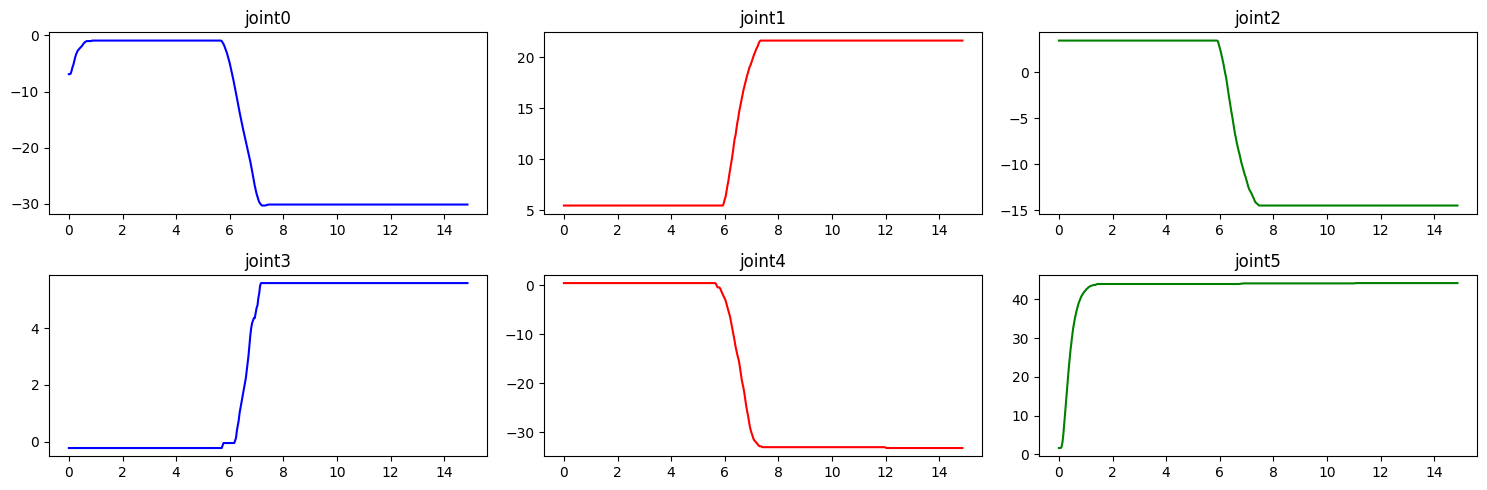

In [65]:
# 데이터 샘플 로드 및 확인 - Timestep vs Observation/Action
import matplotlib.pyplot as plt
import numpy as np

file_num = 1
df = pd.read_parquet(chunk_path / f"file-{file_num:03d}.parquet")

print("\n" + "=" * 70)
print("📊 데이터 샘플 로드")
print("=" * 70)
    
try:   
    # Observation과 Action 함께 시각화

    print(f"file-{file_num:03d}.parquet 파일에서 데이터 샘플을 로드하여 시각화합니다...")

    plt.figure(figsize=(10, 6)) # 그래프 크기 설정

    # 'x_column'과 'y_column'에 본인의 데이터 열 이름을 입력하세요.
    timestamp = df['timestamp']

    observation_state = df['observation.state']
    joint0 = [row[0] for row in observation_state]
    joint1 = [row[1] for row in observation_state]
    joint2 = [row[2] for row in observation_state]
    joint3 = [row[3] for row in observation_state]
    joint4 = [row[4] for row in observation_state]
    joint5 = [row[5] for row in observation_state]

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 5))


    axes[0][0].plot(timestamp, joint0, 'b')
    axes[0][0].set_title('joint0')

    axes[0][1].plot(timestamp, joint1, 'r')
    axes[0][1].set_title('joint1')

    axes[0][2].plot(timestamp, joint2, 'g')
    axes[0][2].set_title('joint2')

    axes[1][0].plot(timestamp, joint3, 'b')
    axes[1][0].set_title('joint3')

    axes[1][1].plot(timestamp, joint4, 'r')
    axes[1][1].set_title('joint4')

    axes[1][2].plot(timestamp, joint5, 'g')
    axes[1][2].set_title('joint5')

    plt.tight_layout() # 그래프 간격 자동 조정
    plt.show()
    
except Exception as e:
    print(f"⚠️  데이터 로드 중 오류: {e}")